Pythonでニューラルネットワークを実装します．ただし，Pythonを使い慣れていない人も多いと思いますので，すべてを実装してもらうようなことはしません．安心してください．

Pythonで実装するにあたり，オライリー・ジャパンの[ゼロから作るDeep Learning](https://www.oreilly.co.jp/books/9784873117584/)を参考にしています．

ニューラルネットワークの実装についてきちんと理解したい，という人には，上記の「ゼロから作る Deep Learning」という本が大変おすすめです．続編も出ています．

最近は，PytorchやKerasなどのライブラリも充実していて，実際にはライブラリを使う方法が主流かと思います．

ファジィ制御の課題と同じく，実際にプログラムを書いてもらいたいところには， **課題(n)** とタイトルをつけて，セル内に`"ここを自分で書く"`と文字列を入れてあります．

pythonの基本的な構文を調べたい場合には，以下のサイトを見てみるとよいでしょう．

- https://www.javadrive.jp/python/
- https://www.tohoho-web.com/python/index.html
- https://note.nkmk.me/python/

# ニューラルネットワークの実装

ニューラルネットワークの式は以下のように表すことができます（授業で紹介した式と同じものです）．

$$
x_{ip} = h_{i}(z_{ip}) \\
z_{ip} = \sum_{j} w_{ij} y_{jp}
$$

$ h_{i}() $ は微分可能な関数で， **活性化関数(activation function)** です．

まずは，活性化関数を紹介しながら，定義していきます．

## 活性化関数

### ステップ関数

パーセプトロンで利用されているのがステップ関数です．

以下の定義を実行してから，実際にステップ関数に引数を与えて，結果を確認してください．

In [40]:
# ステップ関数の定義
def step_function(x):
    if x > 0:
        return 1
    else:
        return 0

In [41]:
# このセルで結果を確認してください．

step_function(10)

1

以下は，ステップ関数のグラフです．

numpyライブラリを使って計算するために，`step_function()`の書き方を少し変更しています．

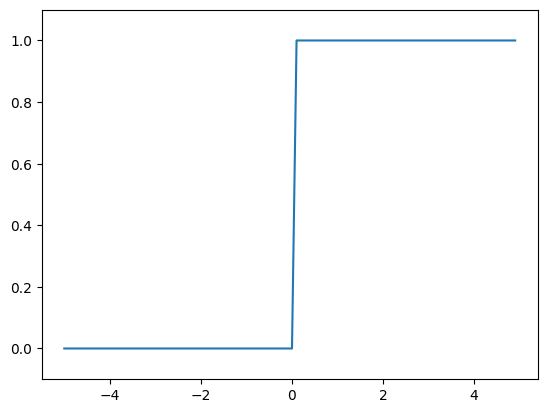

In [42]:
# ステップ関数の定義と，グラフの描画
%matplotlib inline

import numpy as np
import matplotlib.pylab as plt

def step_function(x):
    return np.array(x > 0, dtype=int)
    #  numpy配列xの要素が0より大きければ1，そうでなければ0を要素とした配列を返す

x = np.arange(-5.0, 5.0, 0.1) # -5.0から5.0までの範囲で0.1刻みにnumpy配列を作る
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1) # y軸の範囲を指定する
plt.show()

### シグモイド関数

シグモイド関数は，ニューラルネットワークでよく使われる活性化関数です．2クラスの分類問題に向いています．

$$
h(x) = \frac{1}{1 + exp(-x)}
$$

分母の $ exp(-x) $ は， $ e^{-x} $ のことです．

ステップ関数と同じく，以下のプログラムを実行して，与える引数をいろいろと変えてみましょう．

In [43]:
import numpy as np

# シグモイド関数の定義
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) # 分母のexpはnumpyライブラリの関数を使う

In [44]:
# このセルで，結果を確認してください．
# ステップ関数と同じように，関数名と引数を与えればよいですね
sigmoid(4)


0.9820137900379085

シグモイド関数のグラフを見てみましょう．

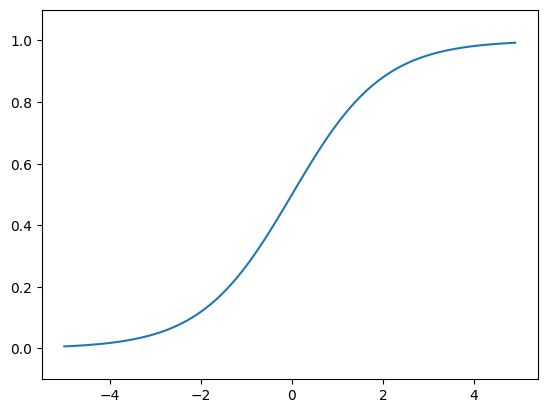

In [45]:
# シグモイド関数の定義と，グラフの描画
%matplotlib inline

import numpy as np
import matplotlib.pylab as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1) # -5.0から5.0までの範囲で0.1刻みにnumpy配列を作る
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1) # y軸の範囲を指定する
plt.show()

### ReLU(Rectified Linear Unit)関数

ReLU関数は以下の式で表されます．

$$
    h(x) =
        \begin{cases}
            x (\quad x > 0) \\
            0 (\quad x \leqq 0) \\
        \end{cases}
$$

In [46]:
import numpy as np

# ReLU関数の定義

def relu(x):
    return np.maximum(0, x) # np.maximum()は，2つの引数のうち，大きい方の値を返す関数

In [47]:
# このセルで，結果を確認してください．
relu(10)

10

ReLU関数の定義とグラフを見てみましょう．

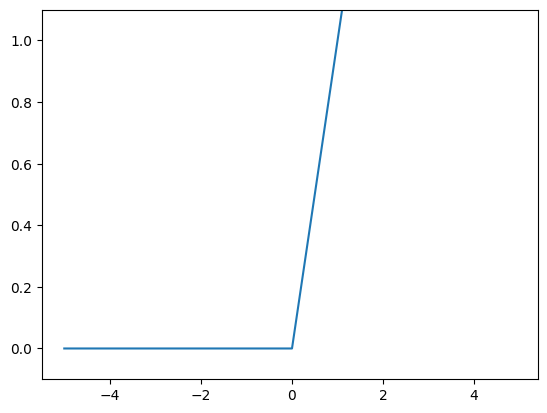

In [48]:
# ReLU関数の定義と，グラフの描画
%matplotlib inline

import numpy as np
import matplotlib.pylab as plt

def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1) # -5.0から5.0までの範囲で0.1刻みにnumpy配列を作る
y = relu(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1) # y軸の範囲を指定する
plt.show()

この他にも，恒等関数，ソフトマックス関数などがあります．

## 3層ニューラルネットワークの実装

まずは，3層ニューラルネットワークの実装をしていきます．

実装する3層ニューラルネットワークは以下のようなネットワークとします．

- 入力層（第0層）はニューロン（ノード）が2つ
- 第1層はニューロンが3つ
- 第2層はニューロンが2つ
- 出力層（第3層）はニューロンが2つ

イメージがわかないというひとは，moodleトピック10の「課題1の補足説明」にある図1を見てください．

### 入力層（第0層）から第1層

入力層（第0層）から第1層目への信号を伝達し，第1層目の1番目のノードの値 $ z_1 $は以下のように書けます．

$ y_1 $ と $y_2$ が入力に相当します．入力パターンの番号を表す $ p $ は省略しています．

そして， $ w_0 $ を $ b $ に置き換えます． $ w_0 $ は**バイアス**とも呼ばれますので，わかりやすく， $b$ としました．

さらに， 変数の右上にある $(1)$ というのは，第1層目の値であることを示します．

$$
z_{1}^{(1)} = w_{11}^{(1)} y_{1} + w_{12}^{(1)} y_{2} + b_{1}^{(1)}
$$

この式を行列の内積を用いて，以下のように書き表すことができます．

$$
\boldsymbol{Z}^{(1)} = \boldsymbol{Y} \boldsymbol{W}^{(1)} + \boldsymbol{B}^{(1)}
$$

行列，ベクトルの要素は以下のとおりです．

$$
\boldsymbol{Z}^{(1)} =
        \left[\begin{array}{ccc}
            % 横並びは&を挟む
            z_{1}^{(1)} & z_{2}^{(1)} & z_{3}^{(1)}
        \end{array}\right] \quad
$$

$$
\boldsymbol{Y} =
        \left[\begin{array}{cc}
            % 横並びは&を挟む
            y_{1} & y_{2}
        \end{array}\right] \quad
$$

$$
\boldsymbol{B}^{(1)} =
        \left[\begin{array}{ccc}
            % 横並びは&を挟む
            b_{1}^{(1)} & b_{2}^{(1)} & b_{3}^{(1)}
        \end{array}\right] \quad
$$

$$
\boldsymbol{W}^{(1)} =
        \left[\begin{array}{ccc}
            % 横並びは&を挟む
            w_{11}^{(1)} & w_{21}^{(1)} & w_{31}^{(1)} \\
            w_{12}^{(1)} & w_{22}^{(1)} & w_{32}^{(1)}            
        \end{array}\right] \quad
$$

では，NumPyの多次元配列と，numpyライブラリの内積を計算する関数`np.dot()`を使って，　$ \boldsymbol{Z}^{(1)} = \boldsymbol{Y} \boldsymbol{W}^{(1)} + \boldsymbol{B}^{(1)} $ を計算するプログラムを書いてみましょう．

In [49]:
Y = np.array([1.0, 0.5]) # 入力信号
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]]) # 第1層目への結合強度
B1 = np.array([0.1, 0.2, 0.3]) # 第1層目へのバイアス

Z1 = np.dot(Y, W1) + B1 # 第1層目のzの値．np.dotで与えたベクトルと行列の内積を計算できる
print(Z1) # print関数で表示する

[0.3 0.7 1.1]


上のプログラムを実行すると，Z1が計算されて，値が表示されたと思います．

次に，求められた $ \boldsymbol{Z}^{(1)} $ を活性化関数 $ h $ へ渡します．

活性化関数は，シグモイド関数を使うことにします．

In [50]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

X1 = sigmoid(Z1) # Z1は上のセルで計算済み
print(X1)

[0.57444252 0.66818777 0.75026011]


さきほど計算したZ1をシグモイド関数へ渡し，第2層の入力となるX1を計算することができました．

ここまでが，入力層から第1層目への信号の伝達となります．

### 第1層から第2層

同様に，第1層から第2層への信号の伝達を表すプログラムを見てみましょう．

Z2を計算する部分と，出力層（第3層）の入力となるX2を計算する部分は，入力層（第0層）から第1層へのところと同じように書けます．

In [51]:
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]]) # 第2層目への結合荷重
B2 = np.array([0.1, 0.2]) # 第2層目へのバイアス

Z2 = np.dot(X1, W2) + B2 # 第2層目のzの値．X1は入力層から第1層の計算で求められた値
X2 = sigmoid(Z2) # Z2をシグモイド関数へ渡し，第2層目からの出力X2を計算

print(X2)

[0.62624937 0.7710107 ]


第1層目から第2層目は中間層での信号の伝達なので，第1層目の出力である $ \boldsymbol{X}^{(1)} $ が，第2層にとっての入力となります．

入力層から第1層へのプログラムと見比べると，同じことをしているというのがわかりますね．

### 第2層から出力層（第3層）

最後に，第2層から出力層（第2層）への信号の伝達を表すプログラムです．

これまでとほとんど同じですが，最後の活性化関数だけが異なります．

まず，最後の活性化関数となる，**恒等関数**を定義します．恒等関数とは，入力をそのまま出力する関数です．

入力がそのまま出力になるので，わざわざ定義しなくてもよいのですが，これまでと同じ形のプログラムにするために定義しておきます．

In [52]:
# 恒等関数の定義
def identity_function(x):
    return x

では，第2層から出力層（第3層）への信号の伝達のプログラムを見てみます．

In [53]:
W3 = np.array([[0.1, 0.3], [0.2, 0.4]]) # 出力層への結合荷重
B3 = np.array([0.1, 0.2]) # 出力層へのバイアス

Z3 = np.dot(X2, W3) + B3 # 出力層のzの値．X2は，第1層から第2層のところで求められた値
OUTPUT = identity_function(Z3) # Z3を恒等関数へ渡し，出力層からの出力OUTPUTを計算

print(OUTPUT)

[0.31682708 0.69627909]


これで，3層ニューラルネットワークの出力を求めることができました．

### 課題(1) 各層のプログラムをまとめて，実行する

3層ニューラルネットワークの各層でのプログラムを見てきました．

ここまでのプログラムをまとめましょう．

`"ここを自分で書く"`となっている部分に，適切なプログラムを書き，実行してください．

In [54]:
import numpy as np

# シグモイド関数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 恒等関数
def identity_function(x):
    return x

# ニューラルネットワークの結合強度とバイアスの値を初期化する関数．
def init_network():
    # 結合強度とバイアスは辞書型で格納する
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['B1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['B2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['B3'] = np.array([0.1, 0.2])
    
    return network


# networkに格納された結合強度とバイアス，入力yから，ネットワークの出力を計算して，numpy配列で返す関数
def forward(network, y):

    # init_network()で初期化した値を各変数に入れる
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    B1, B2, B3 = network['B1'], network['B2'], network['B3']
    
    # 入力層から第1層
    Z1 = np.dot(y, W1) + B1
    X1 = sigmoid(Z1)
    # 第1層から第2層
    Z2 = np.dot(X1, W2) + B2
    X2 = sigmoid(Z2)
    # 第2層から出力層
    Z3 = np.dot(X2, W3) + B3
    OUTPUT = identity_function(Z3)
    
    return OUTPUT


### ここからがメインの処理

network = init_network() # 結合荷重とバイアスを初期化する
Y = np.array([1.0, 0.5]) # ネットワークの入力Y
OUTPUT = forward(network, Y) # 関数forwardに結合荷重とバイアスの変数，入力を与えて，出力を計算する
print(OUTPUT) # 出力OUTPUTの中身を表示する

[0.31682708 0.69627909]


プログラムが正しく書けていれば，`[0.31682708 0.69627909]`と表示されます．

上記では，出力層の活性化関数に恒等関数を使いました．

授業スライドでも解説している通り，問題によって用いる活性化関数は異なります．

（恒等関数は，回帰問題でよく使われます）

また，出力層のニューロンを2つで解説してきましたが，出力層のニューロン数も問題によって異なってきます．

分類問題では分けたいクラス数を出力層のニューロン数にするのが一般的と言われています．

例えば，2クラスにわけたいときは出力層のニューロン数を2，10クラスにわけたいときは10とする，と言った感じです．

## 結合荷重の学習

ここまでは，結合荷重もバイアスも初期値を使ってきました．

ですが，実際には，教師信号（教師データ）を用いて，パラメータを学習しなければなりません．

ということで，パラメータの学習に必要なものを説明・定義していきます．

### 損失関数

**損失関数**とは，ニューラルネットワークの性能の悪さを表す指標です．

損失関数の値が大きいほど性能が悪く，小さいほど性能がよい，と言えます．

よく使われる損失関数として，**2乗和誤差**と**交差エントロピー誤差**があります．

#### 2乗和誤差

$$
    E = \frac{1}{2} \sum_{k} (y_k - t_k)^2
$$

ここで， $ y_k $ はニューラルネットワークの出力， $ t_k $ は教師信号の出力， $ k $ はデータの次元数（教師信号のパターン数）を表します．

これは，第9回の授業資料14ページに登場した，第p番目の入力パターンに対する誤差関数と同じです．

これをプログラムで書くと以下のようになります．引数はnumpy配列が2つ（ネットワークの出力と，教師信号の出力）で，numpy配列のままで引き算と2乗，総和の計算をしています（便利ですね）．

In [55]:
# 2乗和誤差
def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

ためしに，以下のデータで計算をしてみましょう．

In [56]:
# 教師信号の出力
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

# ニューラルネットワークの出力例1
# 教師信号に近い出力だった場合
y1 = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

# 2乗和誤差を計算して，出力する
print("教師信号に近い出力のときの2乗和誤差：")
print(mean_squared_error(np.array(y1), np.array(t))) # tとy1はリストなので，numpy配列にしてから渡す

# ニューラルネットワークの出力例2
# 教師信号に近くない出力だった場合
y2 = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]

# 2乗和誤差を計算して，出力する
print("教師信号に近くない出力のときの2乗和誤差：")
print(mean_squared_error(np.array(y2), np.array(t)))

教師信号に近い出力のときの2乗和誤差：
0.09750000000000003
教師信号に近くない出力のときの2乗和誤差：
0.5975


実行してみると，教師信号に近い値だった場合には2乗和誤差が小さく，教師信号に近くない値だった場合には2乗和誤差が大きいことがわかります．

#### 交差エントロピー誤差

$$
    E = - \sum_{k} t_k \log y_k
$$

これをプログラムで書くと以下のようになります．

In [57]:
# 交差エントロピー誤差
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

変数`delta`に10の-7乗を格納して，logの計算のときに`y`に足しているのは，`np.log(0)`の結果が`-inf`になって計算できなくなるのを防ぐためです．

交差エントロピー誤差についても，2乗和誤差と同じ例で計算をしてみましょう．

In [58]:
# 教師信号の出力
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

# ニューラルネットワークの出力1
# 教師信号に近い出力だった場合
y1 = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]

# 交差エントロピー誤差を計算して，出力する
print("教師信号に近い出力のときの交差エントロピー誤差：")
print(cross_entropy_error(np.array(y1), np.array(t))) # numpy配列にしてから渡す

# ニューラルネットワークの出力2
# 教師信号に近くない出力だった場合
y2 = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]

# 交差エントロピー誤差を計算して，出力する
print("教師信号に近くない出力のときの交差エントロピー誤差：")
print(cross_entropy_error(np.array(y2), np.array(t)))

教師信号に近い出力のときの交差エントロピー誤差：
0.510825457099338
教師信号に近くない出力のときの交差エントロピー誤差：
2.302584092994546


実行してみると，2乗和誤差と同様に，教師信号に近い出力のときに誤差が小さいことがわかります．

### 勾配法

損失関数でニューラルネットワークの性能をはかることができます．あるパラメータでの性能の良し悪しがわかれば，さらに性能を上げるためにパラメータを更新することができます．

つまり，損失関数の値が最も小さくなるような最適なパラメータを見つける，ということです．

最適なパラメータを見つけるための手法として，**勾配法**または**最急降下法**が用いられます．

**勾配法（最急降下法）は，これまでの授業の中で出てきた，結合強度の更新式のことです．**

結合強度の更新式の中に，偏微分が登場していたのは覚えていますか？

ここでは，コンピュータで実装する上でのテクニックとして**数値微分**を使います（みなさんが数学の授業でやっている微分は，**解析的な微分**です）

数値微分は，微分の近似値を求めることができます．

以下のプログラムは数値微分で勾配（すべての変数の偏微分をベクトルとしてまとめたもの）を求めます．

詳しく説明すると長くなりますので，「こういうものだ」と思ってください．

In [59]:
# 数値微分で勾配（すべての変数の偏微分をベクトルにまとめたもの）を求める関数
def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)
        
        x[idx] = tmp_val - h 
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        
        x[idx] = tmp_val # 値を元に戻す
        it.iternext()   
        
    return grad

### 損失関数と勾配法を使ってみる

ここまで出てきた，損失関数と勾配法を使って，ニューラルネットワークの損失関数の勾配を計算してみます．

例として，第0層と第1層からなるネットワークを考えます．第0層は2ニューロン，第1層は3ニューロンで，バイアスはないものとします．

ネットワークのイメージがつかめない人は，moodleトピック11の「課題1の補足説明」にある図2を見てください．

このネットワークの結合強度の行列は以下のように表せます．

$$
\boldsymbol{W} =
        \left[\begin{array}{ccc}
            % 横並びは&を挟む
            w_{11} & w_{21} & w_{31} \\
            w_{12} & w_{22} & w_{32}            
        \end{array}\right] \quad
$$

そして，損失関数を $ L $ で表します．損失関数$L$の勾配は以下のように表せます．

$$
\frac{\partial L}{\partial \boldsymbol{W}} =
        \left[\begin{array}{ccc}
            % 横並びは&を挟む
            \frac{\partial L}{\partial w_{11}} & \frac{\partial L}{\partial w_{21}} & \frac{\partial L}{\partial w_{31}} \\
            \frac{\partial L}{\partial w_{12}} & \frac{\partial L}{\partial w_{22}} & \frac{\partial L}{\partial w_{32}}
        \end{array}\right] \quad
$$

これはつまり， $ \frac{\partial L}{\partial w_{11}} $ は，$ w_{11} $を少し変化させると，$L$がどれだけ変化するか，を表します．

ここでは，損失関数は**2乗和誤差**，活性化関数は**ソフトマックス関数**を使います．

（交差エントロピー誤差を使ってみたい人のために，cross_entropy_error関数の定義も含めてあります）

In [60]:
import numpy as np

# 活性化関数（ソフトマックス関数）
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T 

    x = x - np.max(x) # オーバーフロー対策
    return np.exp(x) / np.sum(np.exp(x))

# 2乗和誤差
def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

# 交差エントロピー誤差
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

# 数値微分で，損失関数の勾配を求める
def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)
        
        x[idx] = tmp_val - h 
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        
        x[idx] = tmp_val # 値を元に戻す
        it.iternext()   
        
    return grad


# 簡単なニューラルネットワークを表すためのクラス
class simpleNet:
    
    # 結合荷重の初期化
    def __init__(self):
        self.W = np.random.randn(2,3) # 結合強度の初期値をランダムに設定する

    # 入力と結合荷重の内積計算
    def predict(self, x):
        return np.dot(x, self.W) # バイアスなしのZを計算する

    # ネットワーク出力と教師信号出力との誤差の計算
    def loss(self, x, t):
        z = self.predict(x) # 入力と結合強度の内積を計算する
        y = softmax(z) # 活性化関数にzを入れてネットワークの出力を求める
        loss =  mean_squared_error(y, t) # ネットワークの出力と，教師信号の出力との2乗和誤差を計算する
        # 交差エントロピー誤差で計算したい場合は，以下のコメントアウトを外す
#         loss = cross_entropy_error(y, t)

        return loss

    
# ここからがメインの処理
x = np.array([0.6, 0.9]) # ニューラルネットワークの入力
t = np.array([0, 0, 1]) # 教師信号の出力

net = simpleNet() # simpleNetクラスのインスタンスを作ると，コンストラクタで結合荷重が初期化される（↑の__init__が実行される）

f = lambda w: net.loss(x, t)  # 数値微分するために関数f(w)を定義する．中身はsimpleNetのloss関数．
dW = numerical_gradient(f, net.W) # 損失関数と，いまのネットワークの結合荷重から，勾配を計算する

print(dW) # 求められた勾配を表示する

[[-0.018674    0.13086083 -0.11218683]
 [-0.028011    0.19629124 -0.16828024]]


損失関数の勾配を求めることができました．結合強度の初期値をランダムに設定しているため，実行するごとに勾配の値は変化します．

勾配の方向に結合強度をずらすことで，損失関数が小さくなる（ニューラルネットワークの性能がよくなる）ということです．

## 実際のデータを使って結合強度を学習する

それでは，実際のデータを使って，ニューラルネットワークの結合強度を学習してみましょう．

ここで使うデータは，定番のアヤメ(iris)データです．情報の学生は，人工知能の授業ですでにアヤメデータを使ってるかも？

http://archive.ics.uci.edu/ml/datasets/Iris

アヤメの品種は3つあります．

- Iris-setosa
- Iris-versicolor 
- Iris-virginica

どんなデータなのか読み込んで表示してみましょう．

In [61]:
import pandas as pd

# irisデータの読み込み
iris = pd.read_csv('./iris.csv', header=None)
iris.columns = ["Sepal Length（がく片の長さ）", "Sepal Width（がく片の幅）", "Petal Length（花びらの長さ）", "Petal Width（花びらの幅）", "品種名"]

# iris データを表示する
iris

,Sepal Length（がく片の長さ）,Sepal Width（がく片の幅）,Petal Length（花びらの長さ）,Petal Width（花びらの幅）,品種名
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### 関数の定義

まずは，必要な関数を定義します．ほとんどはこれまでに登場したものです．

3品種の分類ということは多クラスの分類問題ですので，出力層の活性化関数には**ソフトマックス関数**を使います．

また，ここではバッチ学習させたいので，損失関数の交差エントロピー誤差はバッチ学習に対応させた形で定義します．

In [62]:
import numpy as np

# シグモイド関数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 活性化関数（ソフトマックス関数）
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T 

    x = x - np.max(x) # オーバーフロー対策
    return np.exp(x) / np.sum(np.exp(x))

# 交差エントロピー誤差（バッチ学習対応版）
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
        
    # 教師データがone-hot-vectorの場合、正解ラベルのインデックスに変換
    if t.size == y.size:
        t = t.argmax(axis=1)
             
    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

# 数値微分で勾配を求める関数
def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)
        
        x[idx] = tmp_val - h 
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        
        x[idx] = tmp_val # 値を元に戻す
        it.iternext()   
        
    return grad

### 課題(2) 2層ニューラルネットワークの準備

次に2層ニューラルネットワークのクラスを用意します．これは，任意のニューロン数に対応できるプログラムになっています．

**関数predictの中身を一部，自分で書いてください．**ここまで書いたことと同じように書けますね．

In [63]:
import numpy as np

# 2層ニューラルネットワークのクラス
class TwoLayerNet:

    # 結合強度の初期化
    # input_sizeは入力層のニューロン数，hidden_sizeは第1層（隠れ層）のニューロン数，output_sizeは出力層のニューロン数
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size) # 結合強度はランダムに設定する
        self.params['b1'] = np.zeros(hidden_size) # バイアスは0にする
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    # ネットワークの計算
    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
    
        # 第0層から第1層の計算
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1) # 第1層の出力はシグモイドで．
        # 第1層から第2層の計算
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2) # 第2層の出力はソフトマックスで．
        
        return y
        
    # 損失関数を計算．xは入力データ, tは教師信号
    def loss(self, x, t):
        y = self.predict(x) # ネットワークの計算はpredict関数で行う
        return cross_entropy_error(y, t) # 出力yと教師信号出力tを交差エントロピー誤差で計算して返す
    
    # 認識精度を計算
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    # 勾配を計算．xは入力データ, tは教師信号
    def numerical_gradient(self, x, t):
        # 関数loss_W(W)を定義する．中身は↑のloss関数．
        loss_W = lambda W: self.loss(x, t)
        
        # 各層での勾配を辞書型で格納する
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1']) # ここのnumerical_gradient関数は，上のセルで定義したほうの関数．
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        
        return grads

それでは，実際にアヤメデータを使って，パラメータの学習をして，認識精度を確認してみます．

アヤメの品種名をニューラルネットワークで扱えるように，

- Iris-setosa : 1, 0, 0
- Iris-versicolor : 0, 1, 0
- Iris-virginica : 0, 0, 1

に置き換えた教師データ`iris_train.csv`と，テストデータ`iris_test.csv`を読み込みます．

train acc, test acc | 0.3333333333333333, 0.3333333333333333
train acc, test acc | 0.3333333333333333, 0.3333333333333333
train acc, test acc | 0.3333333333333333, 0.3333333333333333
train acc, test acc | 0.3333333333333333, 0.3333333333333333
train acc, test acc | 0.3333333333333333, 0.3333333333333333
train acc, test acc | 0.6666666666666666, 0.6666666666666666
train acc, test acc | 0.3333333333333333, 0.3333333333333333
train acc, test acc | 0.6533333333333333, 0.6666666666666666
train acc, test acc | 0.3333333333333333, 0.3466666666666667
train acc, test acc | 0.3333333333333333, 0.3333333333333333
train acc, test acc | 0.68, 0.6666666666666666
train acc, test acc | 0.6666666666666666, 0.6666666666666666
train acc, test acc | 0.84, 0.88
train acc, test acc | 0.92, 0.8533333333333334
train acc, test acc | 0.96, 0.96
train acc, test acc | 0.6666666666666666, 0.6666666666666666
train acc, test acc | 0.7466666666666667, 0.76
train acc, test acc | 0.6666666666666666, 0.6666666666666666


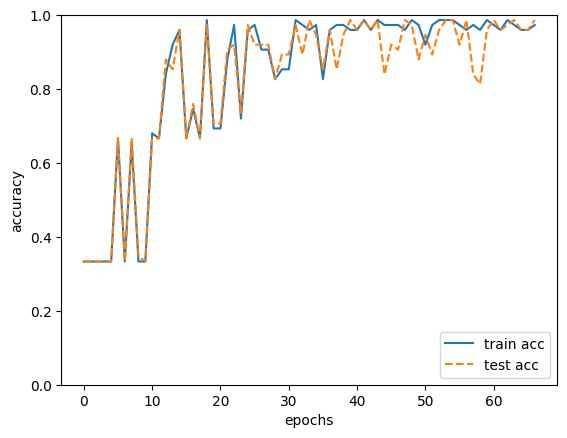

In [64]:
# パラメータの学習と，認識精度の確認
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# データの読み込み
# 学習データ
train = pd.read_csv('./iris_train.csv', header=None)
train_np = np.array(train.values.flatten())
train_array = np.reshape(train_np, (train.shape[0], train.shape[1]))
x_train = train_array[0:, 0:4].astype(np.float32)
t_train = train_array[0:, 4:].astype(np.float32)

# 教師データ
test = pd.read_csv('./iris_test.csv', header=None)
test_np = np.array(test.values.flatten())
test_array = np.reshape(test_np, (test.shape[0], test.shape[1]))
x_test = test_array[0:, 0:4].astype(np.float32)
t_test = test_array[0:, 4:].astype(np.float32)

# 2層のニューラルネットワークを作る
# アヤメの特徴は4種類なので入力は4つ，3品種の分類をしたいので出力は3つ
network = TwoLayerNet(input_size=4, hidden_size=10, output_size=3)

iters_num = 1000  # 繰り返しの回数を適宜設定する
train_size = x_train.shape[0]
batch_size = 5 # データを5個ずつ読む
learning_rate = 0.1 # 学習率

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

# 繰り返し回数分だけ，学習を行う
for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 勾配の計算
    grad = network.numerical_gradient(x_batch, t_batch)
    
    # パラメータの更新
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key] # 勾配法（最急降下法）で更新
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    # データ1周ごとに認識精度を計算する
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

# グラフの描画
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
# plt.savefig('nn-iris.png') # グラフを画像で保存したいときはコメントアウトを外して実行
plt.show()

グラフの横軸が，データ1周した回数（専門用語でエポックといいます）です．

グラフの縦軸が，認識精度です．1.0に近いほど，精度がよいです．

実線が学習データ(train)を使ったときの精度，点線がテストデータ(test)を使ったときの精度です．

**課題(2)** で自分で書いたプログラムが正しければ，学習データ(train)も，テストデータ(test)も，1.0に近くなっていくはずです．

1.0に近づいているようなグラフになっていれば，結合強度の学習がうまくいったということで，ニューラルネットワークの認識精度が向上したと言えます．

ここまでに出てきた内容を使ってようやく逆誤差伝播法が実装できます．

逆誤差伝播法の実装は，別のノートブックを使って行います．ここまでの作業内容を保存して，このノートブックをmoodleで提出してください．